In [1]:
import re

import matplotlib.pyplot as plt
import pandas as pd

# Read Logs

In [2]:
def read_logs_as_raw_string(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.read()
            
            # This represents the data as a raw string format
            raw_content = r"{}".format(content)
            
            return raw_content
    except FileNotFoundError:
        return "Error."

In [3]:
logs_MAPS_file_path = 'MAPS/logs_MAPS.txt' 
logs_our_method = read_logs_as_raw_string(logs_MAPS_file_path)

In [4]:
logs_qmix_file_path="qmix/results/qmixwd_20251217_210538/training_success_rate.csv"
logs_vn_maddpg_file_path="maddpg/results/vn_maddpg_20251219_005049/training_log.csv"

## Parse the logs

In [5]:
def parse_our_method(logs_our_method):
    pattern1 = re.compile(
            r"Episode (\d+).*?Result: (Success|Collision) \| Reward: ([\-?\d\.]+) \| Steps: (\d+)",
            re.DOTALL
        )
    episodes1 = [
        {
            'episode': int(m.group(1)),
            'result': m.group(2),
            'reward': float(m.group(3)),
            'steps': int(m.group(4))
        }
        for m in pattern1.finditer(logs_our_method)
    ]
    df = pd.DataFrame(episodes1)
    return df

In [6]:
def parse_maddpg_method(logs_maddpg_method):
    pattern2 = re.compile(
        r"Episode (\d+) ended with.*?\nINFO:src\.training\.episode_utils:Result: (Success|Collision) \| Reward: ([\-?\d\.]+) \| Steps: (\d+)"
    )
    episodes2 = [
        {
            'episode': int(m.group(1)),
            'result': m.group(2),
            'reward': float(m.group(3)),
            'steps': int(m.group(4))
        }
        for m in pattern2.finditer(logs_maddpg_method)
    ]
    df = pd.DataFrame(episodes2)
    return df

In [7]:
def parse_qmix_method(file_path):
    # Read the CSV file
    df = pd.read_csv(file_path)

    # Rename columns to match the expected schema in your helpers
    df = df.rename(columns={
        "Episode": "episode",
        "Reward": "reward",
        "Episode_Length": "steps"
    })

    # Transform the binary 'Success' column into the 'result' column with string values
    # This ensures calculate_success_rate and calculate_collision_rate work correctly.
    # We assume 0 maps to 'Collision' to satisfy the collision helper.
    df['result'] = df['Success'].map({1: 'Success', 0: 'Collision'})

    # Drop the old 'Success' column to keep it clean (optional)
    df = df.drop(columns=['Success'])

    return df

# Plot Comparison

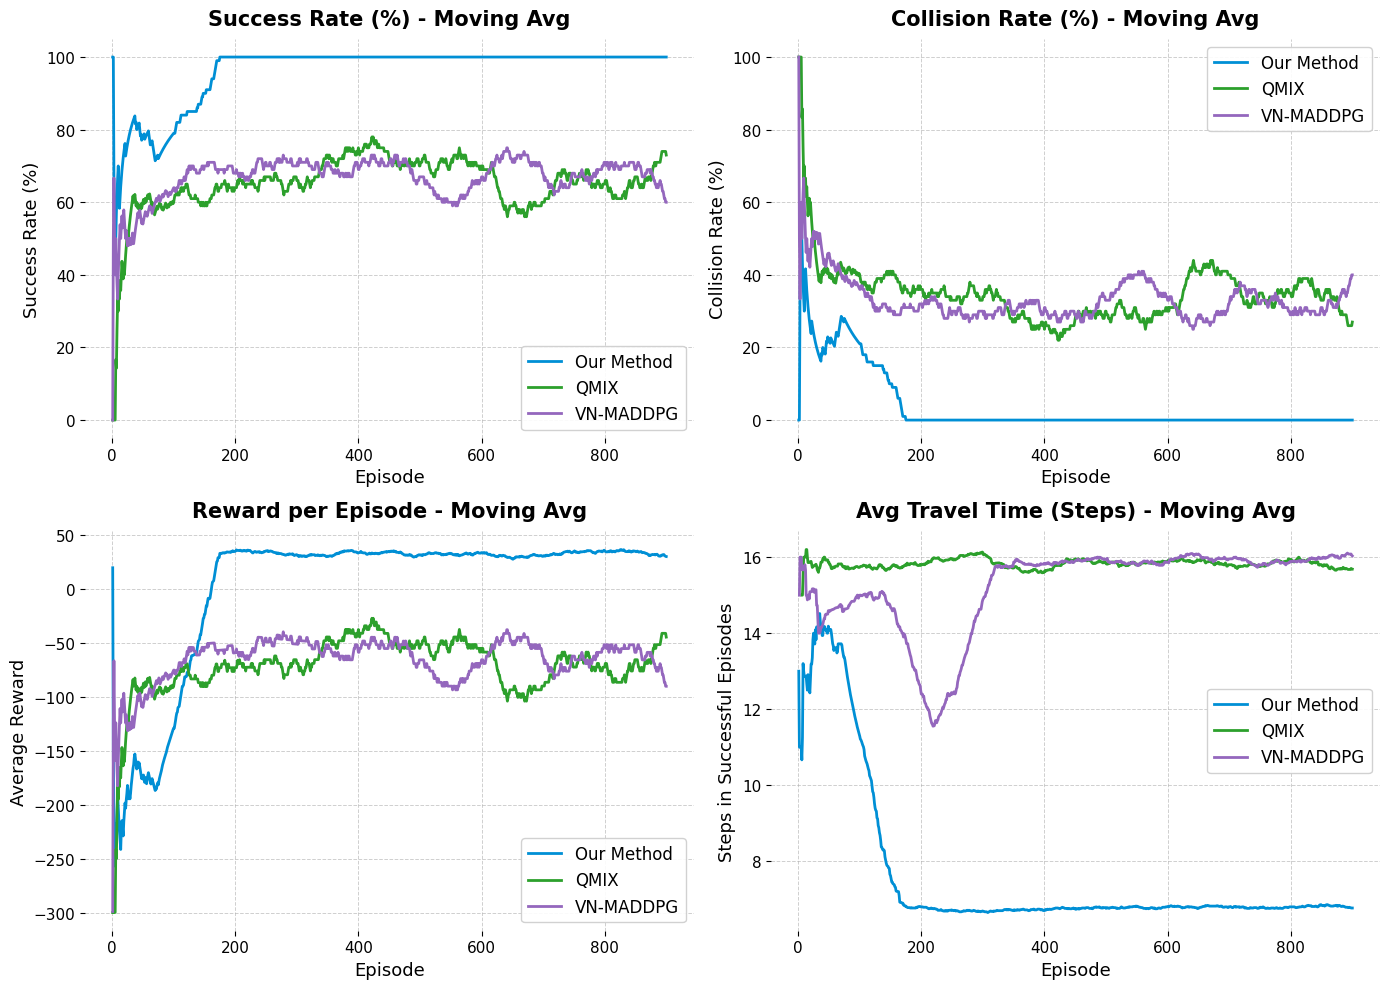

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. New Parser for VN-MADDPG ---
def parse_vn_maddpg_method(file_path):
    """Parses the VN-MADDPG log CSV file."""
    df = pd.read_csv(file_path)
    return df

# --- 2. Metric Calculation Helpers (Existing) ---
def calculate_success_rate(df: pd.DataFrame, window: int) -> pd.Series:
    return (df['result'] == 'Success').astype(int).rolling(window, min_periods=1).mean() * 100

def calculate_collision_rate(df: pd.DataFrame, window: int) -> pd.Series:
    return (df['result'] == 'Collision').astype(int).rolling(window, min_periods=1).mean() * 100

def calculate_avg_reward(df: pd.DataFrame, window: int) -> pd.Series:
    return df['reward'].rolling(window, min_periods=1).mean()

def calculate_travel_time(df: pd.DataFrame, window: int) -> pd.Series:
    success_mask = (df['result'] == 'Success')
    successful_steps = df['steps'].where(success_mask) 
    return successful_steps.rolling(window, min_periods=1).mean()

# --- 3. Styling Helper (Existing) ---
def apply_plot_style(ax, title, ylabel):
    ax.set_title(title, fontsize=15, fontweight='bold', pad=10)
    ax.set_xlabel('Episode', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.legend(fontsize=12, frameon=True, facecolor='white', framealpha=0.9)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_facecolor('white')
    ax.tick_params(axis='both', which='major', labelsize=11)

# --- 4. Updated Plot Function (MADDPG Removed) ---
def plot_log_comparison(logs_our_method, logs_qmix_method, logs_vn_maddpg_method, window=20):
    """
    Parses logs and plots a 2x2 comparison grid of performance metrics.
    Now supports 3 methods: Our Method, QMIX, and VN-MADDPG.
    """
    # 1. Parse Dataframes
    # Note: parse_our_method and parse_qmix_method must be defined in previous cells
    df_our = parse_our_method(logs_our_method)
    df_qmix = parse_qmix_method(logs_qmix_method)
    df_vn_maddpg = parse_vn_maddpg_method(logs_vn_maddpg_method)

    # 2. Prepare Data Sources Configuration
    data_sources = [
        {
            'label': 'Our Method',
            'df': df_our,
            'color': '#008FD5' # Blue
        },
        {
            'label': 'QMIX',
            'df': df_qmix,
            'color': '#2CA02C' # Green
        },
        {
            'label': 'VN-MADDPG',
            'df': df_vn_maddpg,
            'color': '#9467bd' # Purple
        }
    ]
    
    # 3. Define Metrics Configuration
    metrics_config = [
        {
            'title': 'Success Rate (%) - Moving Avg',
            'ylabel': 'Success Rate (%)',
            'func': calculate_success_rate
        },
        {
            'title': 'Collision Rate (%) - Moving Avg',
            'ylabel': 'Collision Rate (%)',
            'func': calculate_collision_rate
        },
        {
            'title': 'Reward per Episode - Moving Avg',
            'ylabel': 'Average Reward',
            'func': calculate_avg_reward
        },
        {
            'title': 'Avg Travel Time (Steps) - Moving Avg',
            'ylabel': 'Steps in Successful Episodes',
            'func': calculate_travel_time
        }
    ]

    # 4. Setup Plot
    plt.style.use('default')
    fig, axs = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
    axs_flat = axs.flatten()

    # 5. Plotting Loop
    for ax, metric in zip(axs_flat, metrics_config):
        
        # Plot each data source on the current axis
        for source in data_sources:
            label = source['label']
            color = source['color']
            df_to_use = source['df']
            
            # Calculate y-values
            y_values = metric['func'](df_to_use, window)
            
            # Plot
            ax.plot(
                df_to_use['episode'], 
                y_values, 
                label=label, 
                linewidth=2, 
                color=color
            )
        
        # Apply styling to the current axis
        apply_plot_style(ax, metric['title'], metric['ylabel'])

    plt.tight_layout()
    plt.show()

# --- 5. Example Execution ---
plot_log_comparison(
    logs_our_method=logs_our_method,
    logs_qmix_method=logs_qmix_file_path,
    logs_vn_maddpg_method=logs_vn_maddpg_file_path, 
    window=100
)

## Calculate Avg steps

In [10]:
df_qmix = parse_qmix_method(logs_qmix_file_path)
df_vn_maddpg = parse_vn_maddpg_method(logs_vn_maddpg_file_path)

In [12]:
avg_steps = df_qmix['steps'].mean()
print(f"Average Steps: {avg_steps}")

Average Steps: 13.20888888888889


In [17]:
# result_counts = df_qmix['result'].value_counts()
# print(result_counts)
# 
# # To specifically access the number of collisions:
# num_crashes = result_counts.get('Collision', 0)
# print(f"Total Crashes: {num_crashes}")

In [14]:
avg_steps = df_vn_maddpg['steps'].mean()
print(f"Average Steps: {avg_steps}")

Average Steps: 12.734444444444444


In [16]:
# result_counts = df_vn_maddpg['result'].value_counts()
# print(result_counts)
# 
# # To specifically access the number of collisions:
# num_crashes = result_counts.get('Collision', 0)
# print(f"Total Crashes: {num_crashes}")